# Nama:
# NIM:
# Kelas:

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [2]:
df = pd.read_csv('WineQT.csv')

## EDA

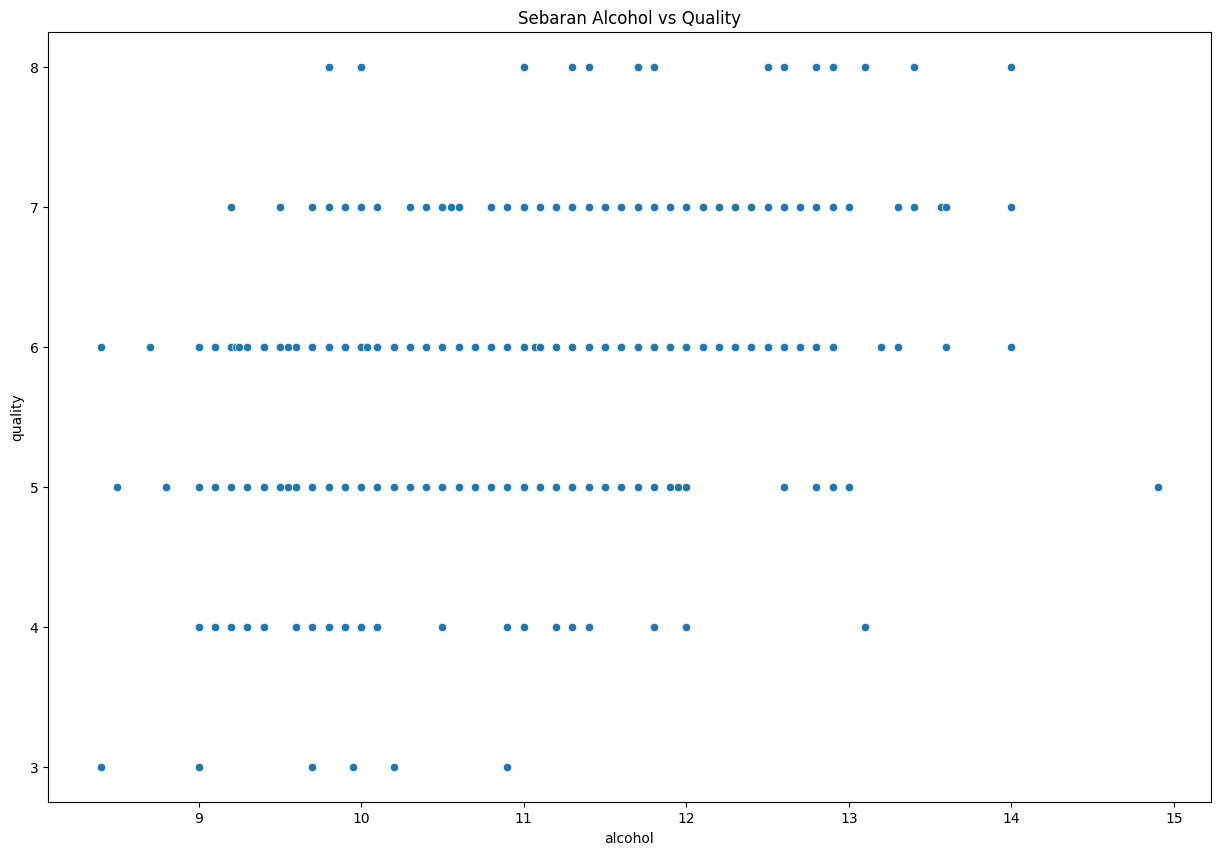

In [10]:
fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    data=df,
    x='alcohol',
    y='quality'
)

plt.title('Sebaran Alcohol vs Quality')
plt.show()

In [11]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


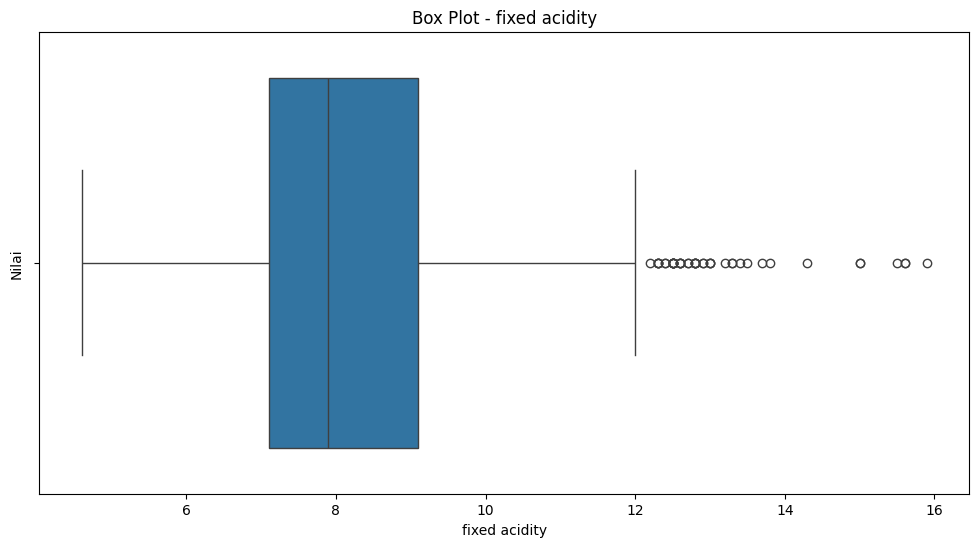

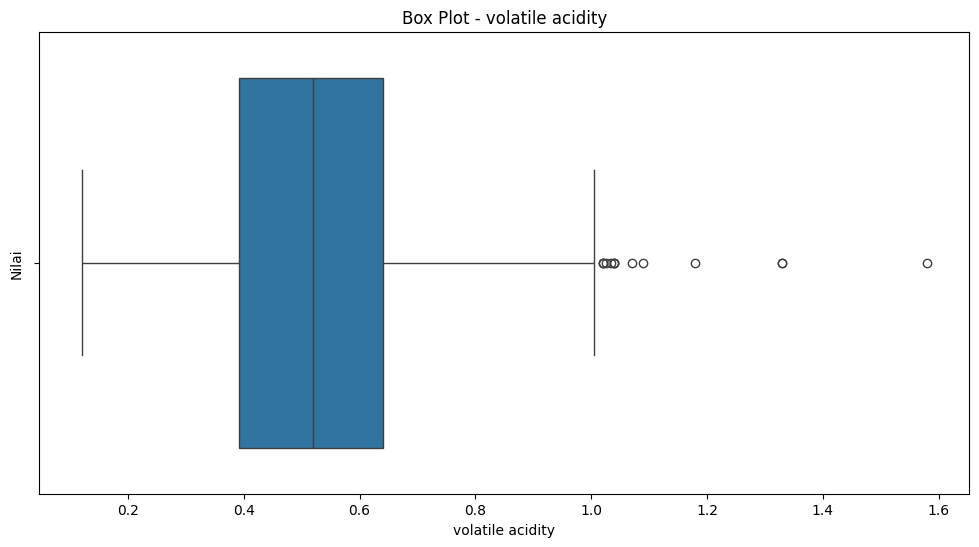

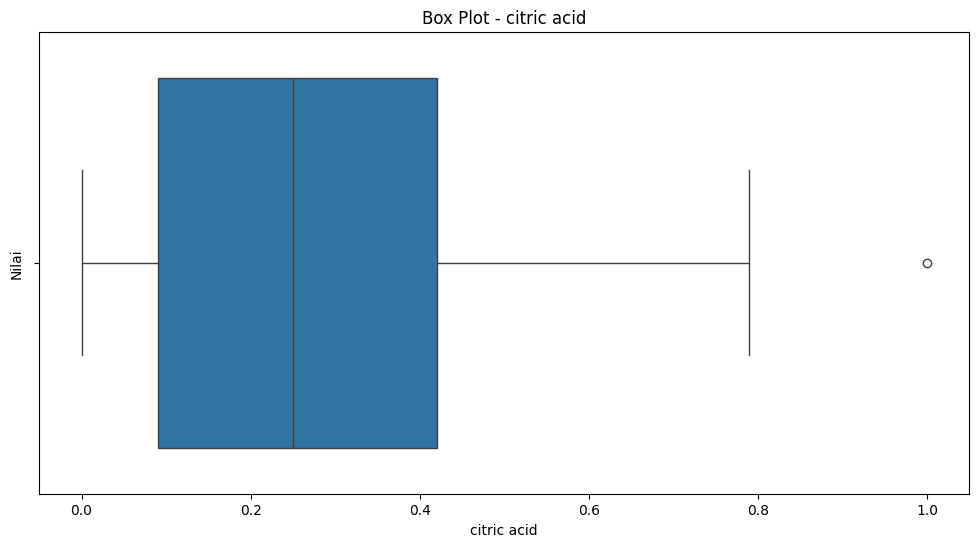

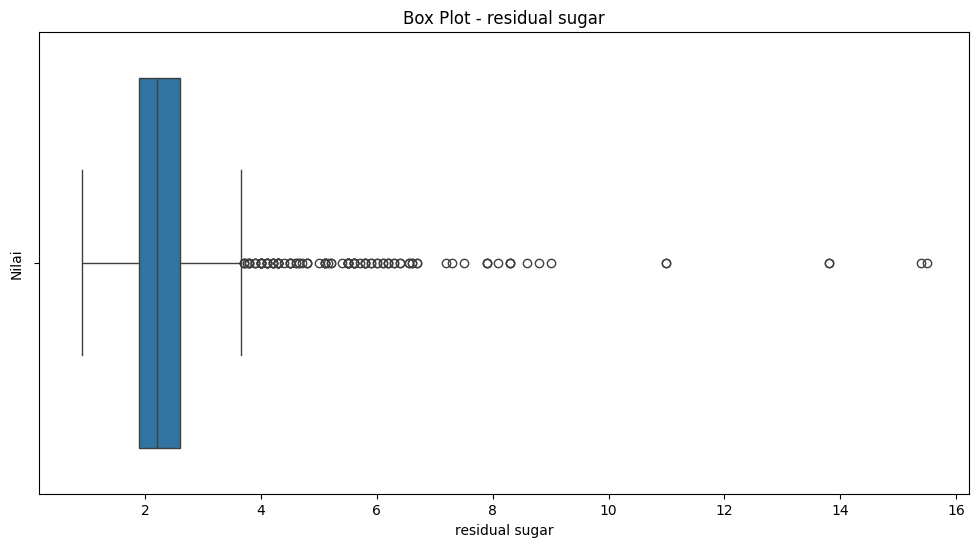

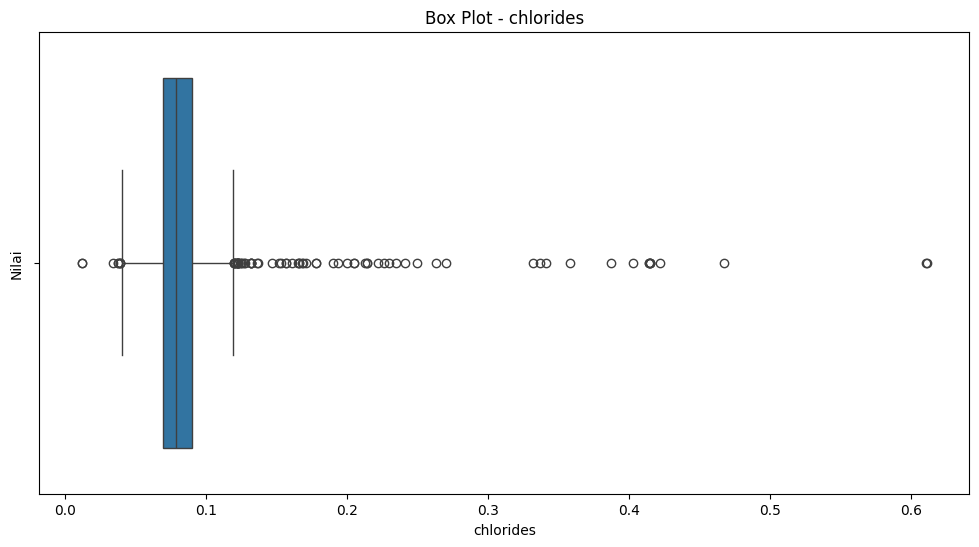

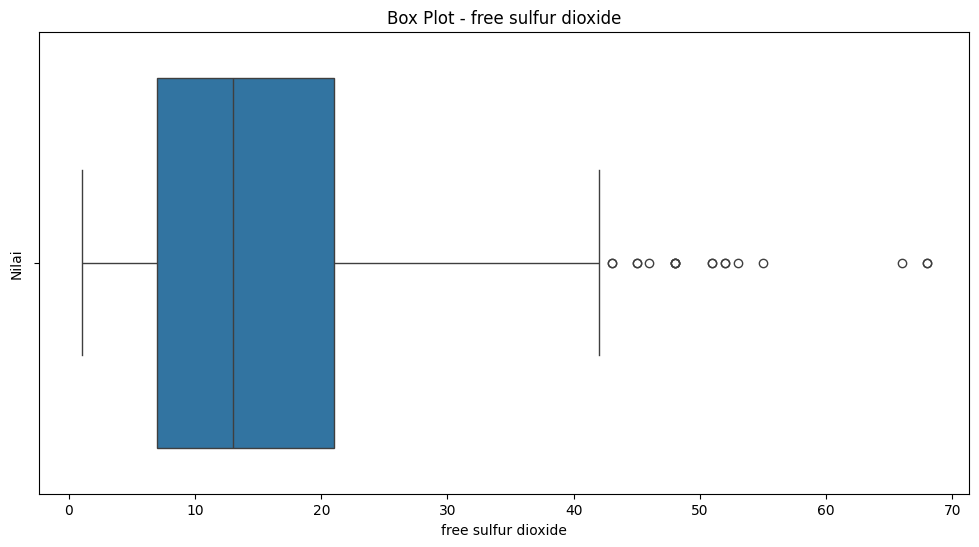

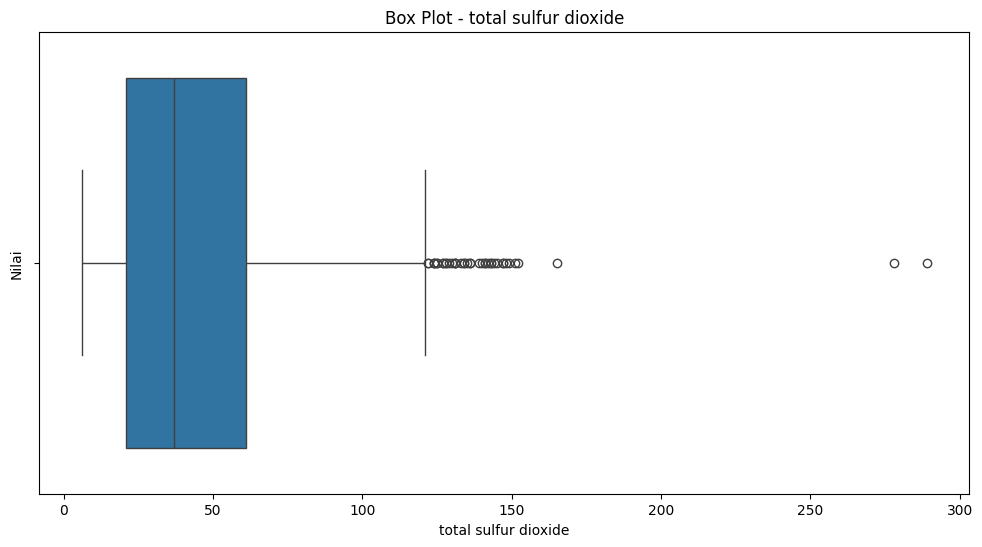

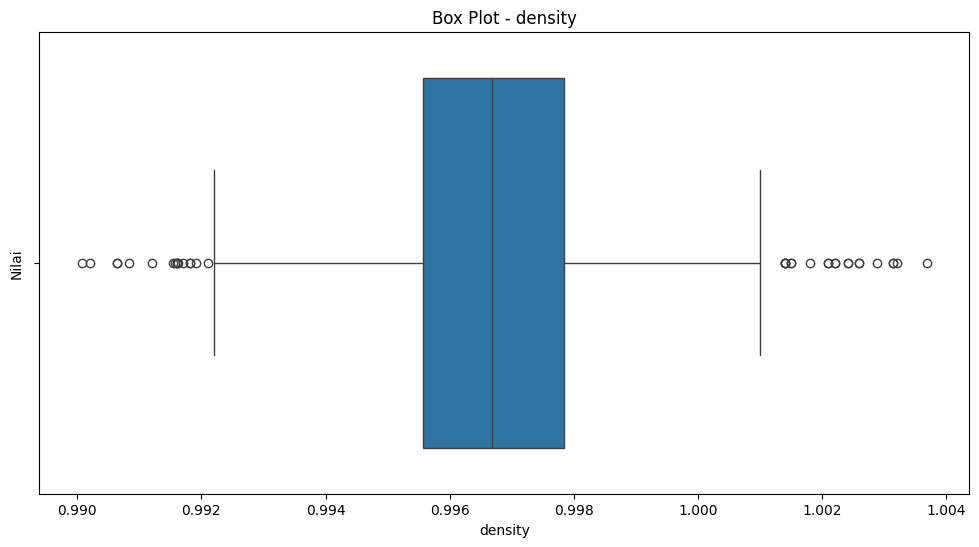

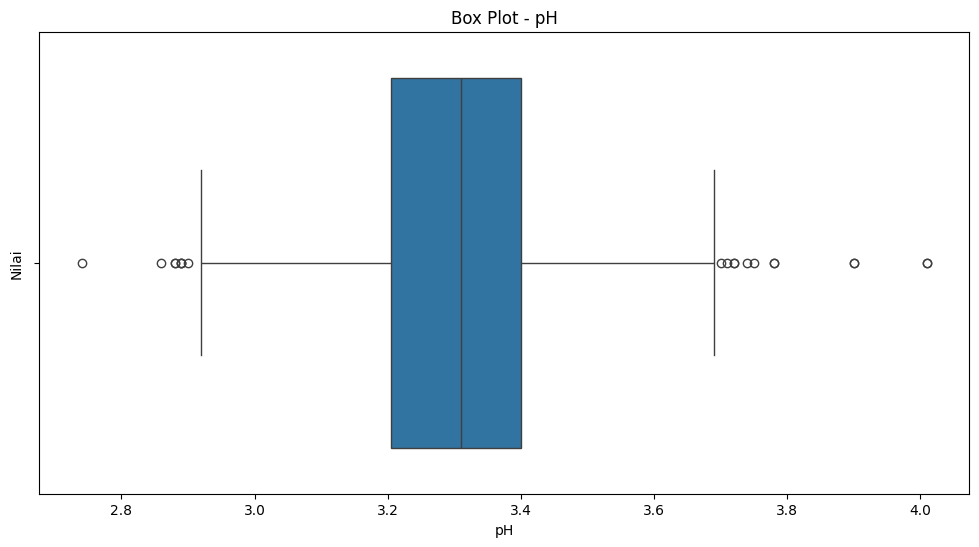

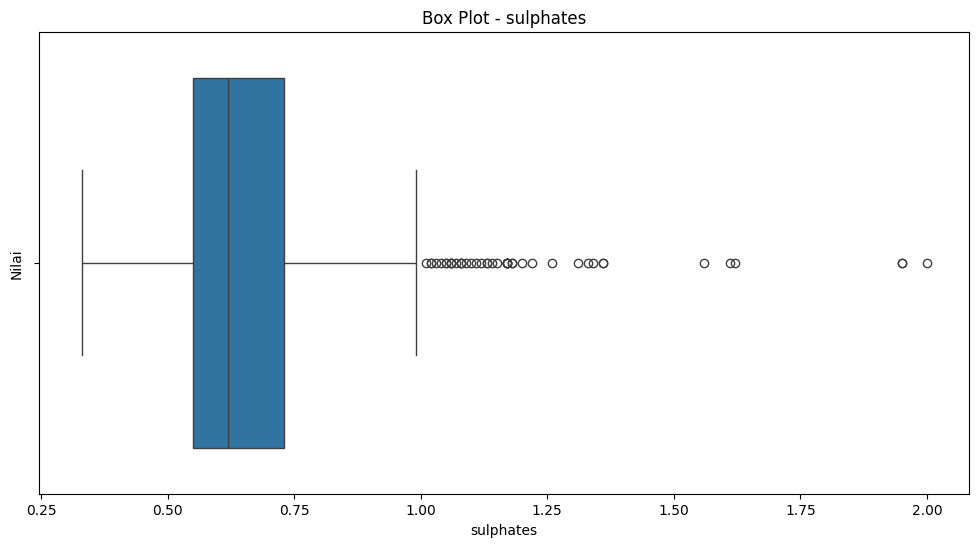

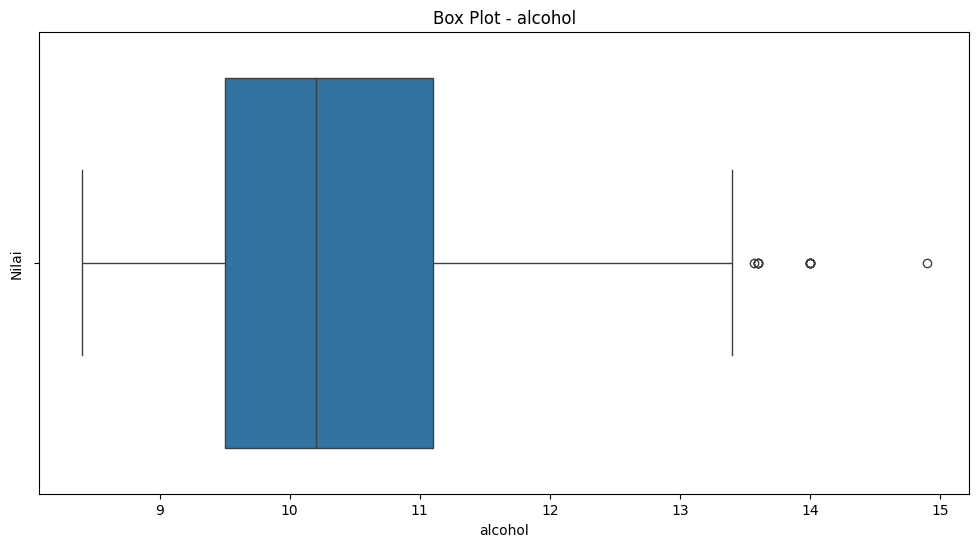

In [18]:
# Looping untuk kolom numerik pada dataset WineQT
columns = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

for col in columns:
    plt.figure(figsize=(12,6))

    sns.boxplot(x=df[col])

    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')

    plt.show()

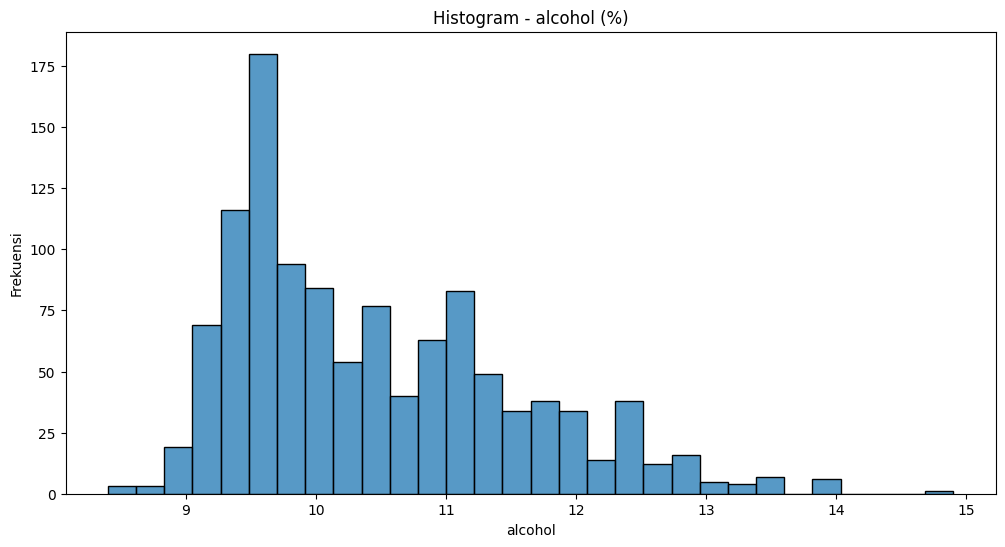

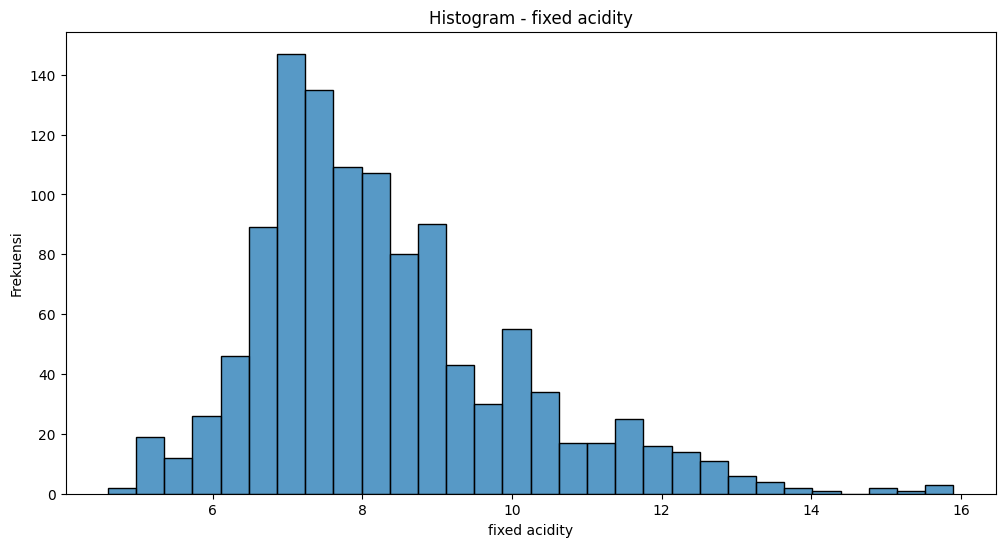

In [20]:
for col in columns:
    plt.figure(figsize=(12, 6))

    sns.histplot(df[col], bins=30, kde=False)

    if col == 'alcohol':
        plt.title(f'Histogram - {col} (%)')
    elif col == 'pH':
        plt.title(f'Histogram - {col}')
    else:
        plt.title(f'Histogram - {col}')

    plt.xlabel(col)
    plt.ylabel('Frekuensi')

    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [21]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [22]:
fitur_columns = ['alcohol', 'fixed acidity']
X = df[fitur_columns].values
y = df['quality'].values # Using 'quality' as the label for clustering comparison

In [23]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,alcohol,fixed acidity
count,1.143000e+03,1.143000e+03
mean,-1.193563e-15,-3.729883e-16
std,1.000438e+00,1.000438e+00
min,-1.887834e+00,-2.124483e+00
25%,-8.709366e-01,-6.933192e-01
50%,-2.238203e-01,-2.353469e-01
75%,6.081863e-01,4.516116e-01
max,4.121103e+00,4.344377e+00


In [24]:
X_std

array([[-0.96338181, -0.52157961],
       [-0.59360107, -0.29259344],
       [-0.59360107, -0.29259344],
       ...,
       [ 0.05351522, -1.20853813],
       [ 0.70063152, -1.38027776],
       [-0.22382033, -1.38027776]])

In [25]:
df_scalling

,alcohol,fixed acidity
0,-0.963382,-0.521580
1,-0.593601,-0.292593
2,-0.593601,-0.292593
3,-0.593601,1.653789
4,-0.963382,-0.521580
...,...,...
1138,0.515741,-1.151292
1139,-0.870937,-0.865059
1140,0.053515,-1.208538
1141,0.700632,-1.380278


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

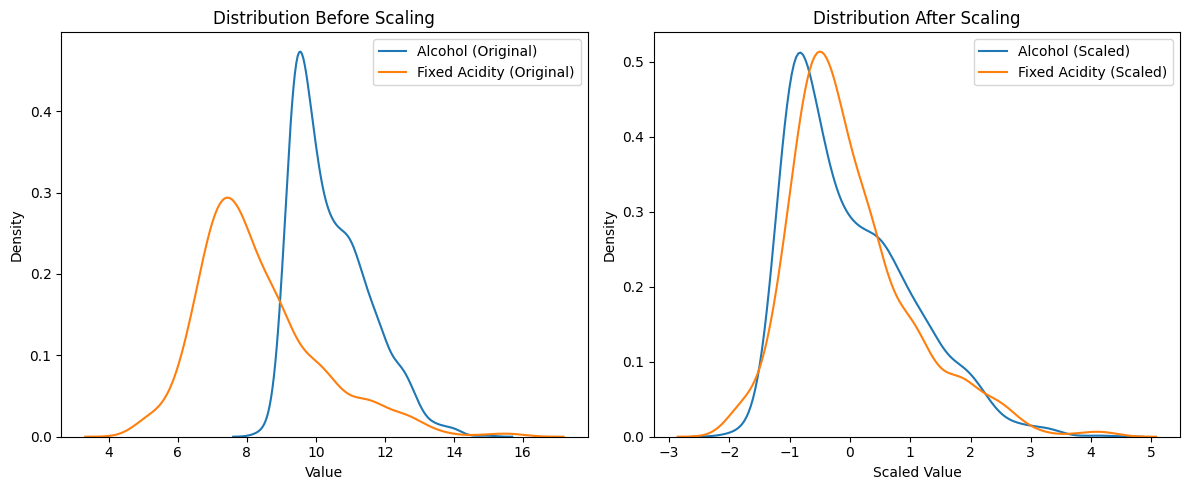

In [26]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler
sns.kdeplot(df['alcohol'], ax=ax1, label='Alcohol (Original)')
sns.kdeplot(df['fixed acidity'], ax=ax1, label='Fixed Acidity (Original)')
ax1.set_title('Distribution Before Scaling')

# Plot distribusi setelah Standar Scaler
sns.kdeplot(df_scalling['alcohol'], ax=ax2, label='Alcohol (Scaled)')
sns.kdeplot(df_scalling['fixed acidity'], ax=ax2, label='Fixed Acidity (Scaled)')
ax2.set_title('Distribution After Scaling')

# Set x-labels
ax1.set_xlabel('Value')
ax2.set_xlabel('Scaled Value')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

terlihat perubahan skala sebelum menggunakan standar scaller dan sesudah standard scaller walau masih memiliki pola yang sama. terlihat juga distribusinya lebih simetris seperti distribusi normal.

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. ....


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

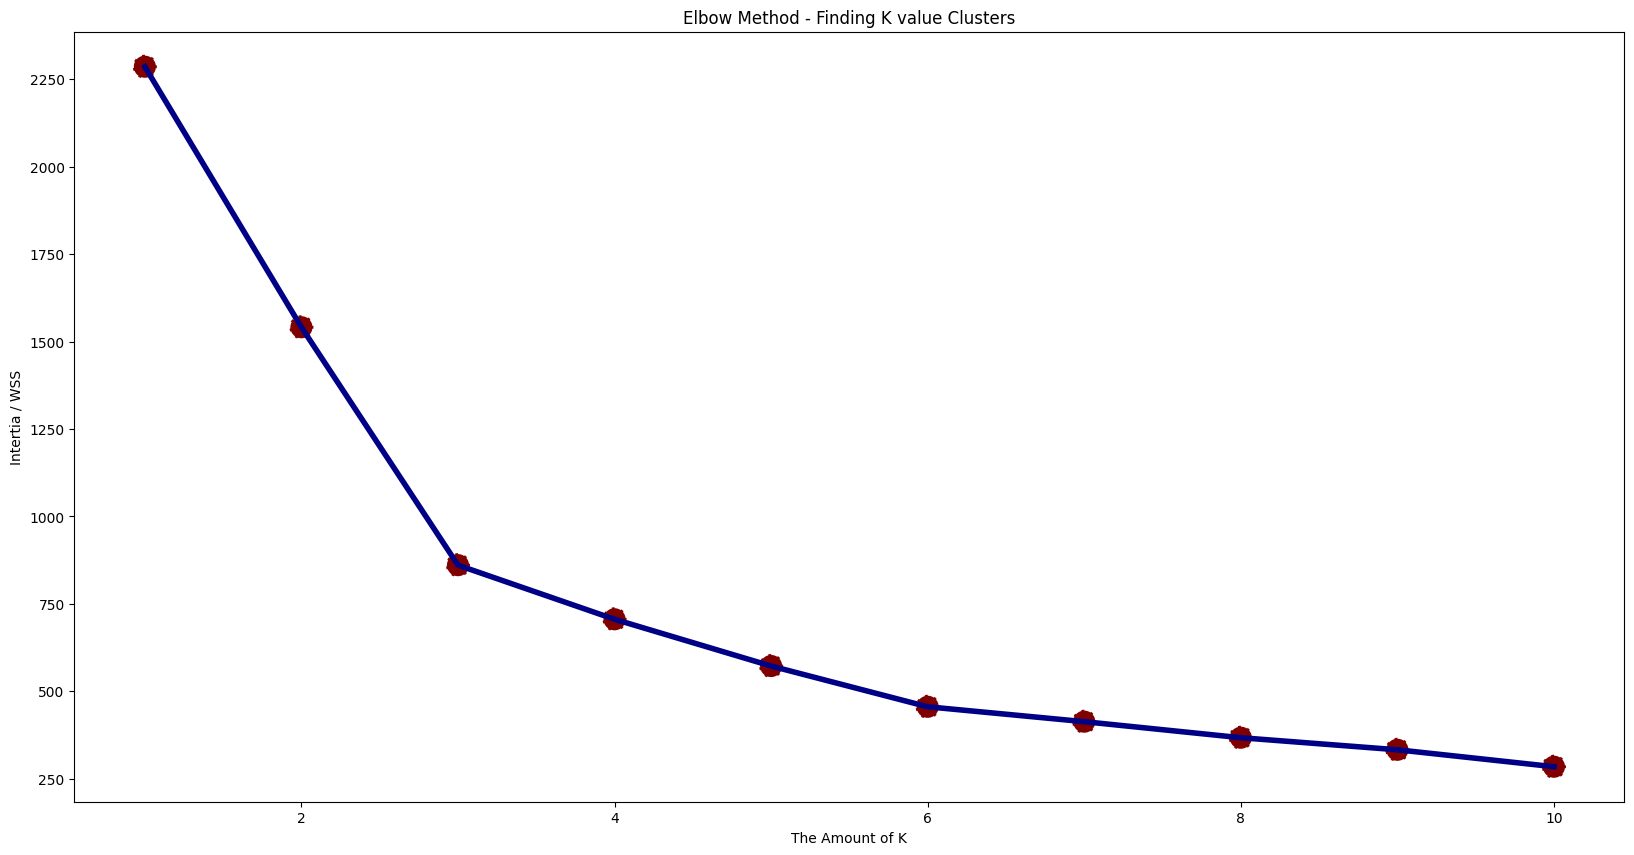

In [27]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [29]:
# Berdasarkan hasil Elbow Method, jumlah cluster optimal adalah 3
# karena terbentuk titik siku (elbow) pada K=3

from sklearn.cluster import KMeans

kmeans_elbow = KMeans(
    n_clusters=3,
    random_state=0
)

kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [30]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [31]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,2


Text(0.5, 1.0, 'Clusters by Elbow Method (Alcohol vs Fixed Acidity)')

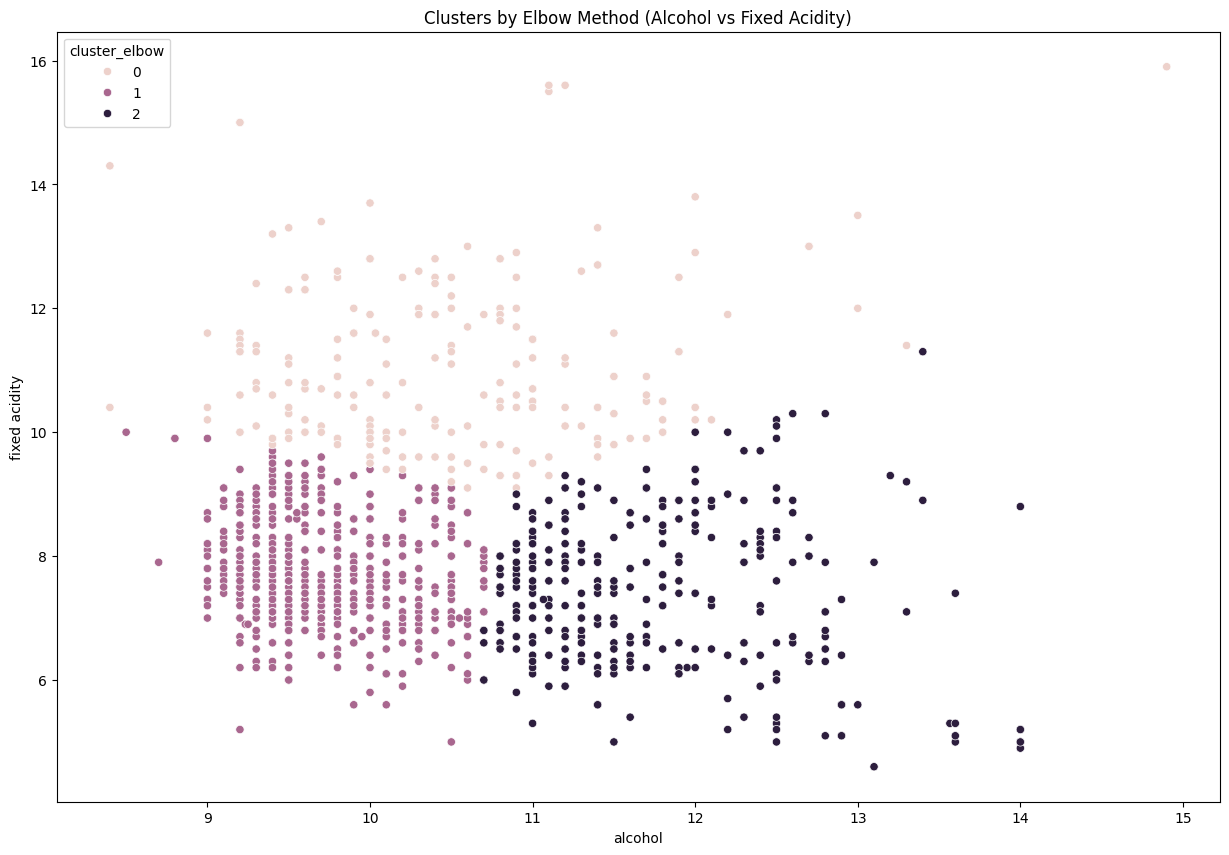

In [32]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_elbow')
plt.title('Clusters by Elbow Method (Alcohol vs Fixed Acidity)')

### Bandingkan hasil dengan label anotator

Text(0.5, 1.0, 'Original Quality Labels (Alcohol vs Fixed Acidity)')

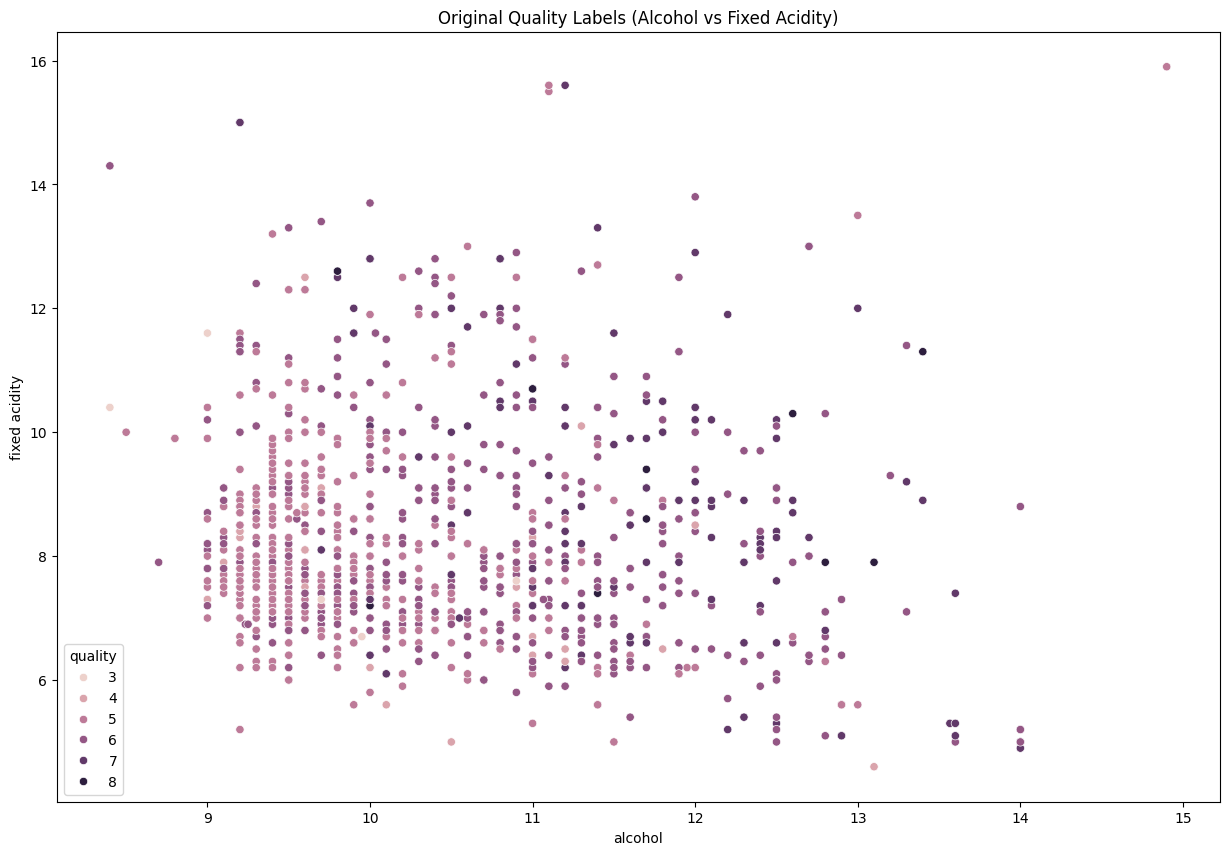

In [33]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity',hue='quality')
plt.title('Original Quality Labels (Alcohol vs Fixed Acidity)')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [34]:
!pip install yellowbrick

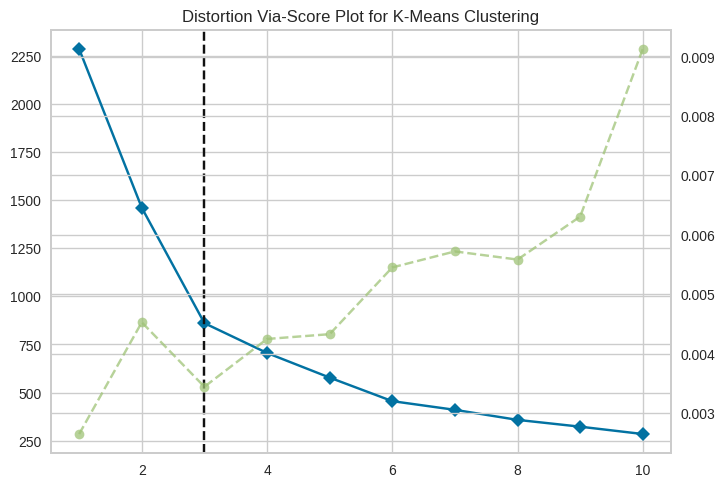

In [35]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [36]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [37]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [38]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,2,2


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

Text(0.5, 1.0, 'Clusters by Via Score Plot (Alcohol vs Fixed Acidity)')

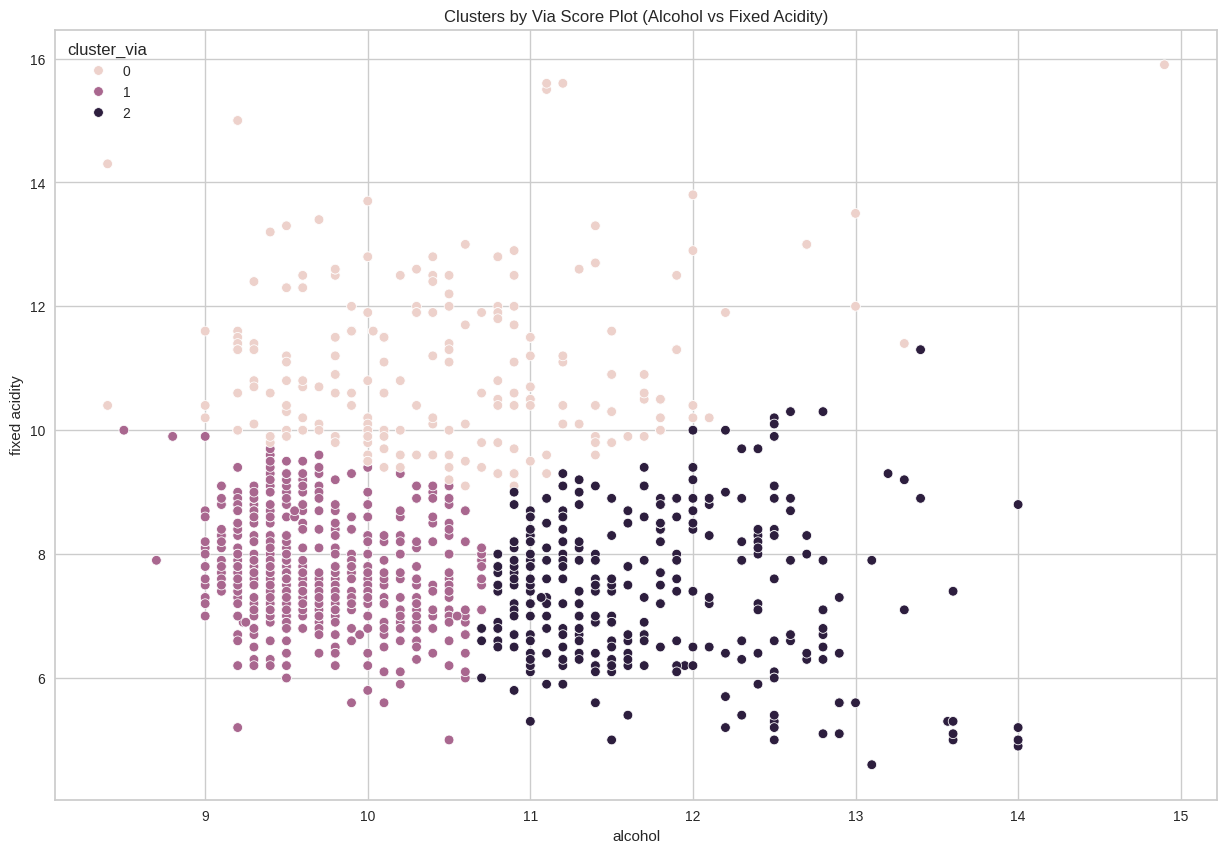

In [39]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_via')
plt.title('Clusters by Via Score Plot (Alcohol vs Fixed Acidity)')

### Bandingkan dengan label anotator

Text(0.5, 1.0, 'Original Quality Labels for Comparison (Alcohol vs Fixed Acidity)')

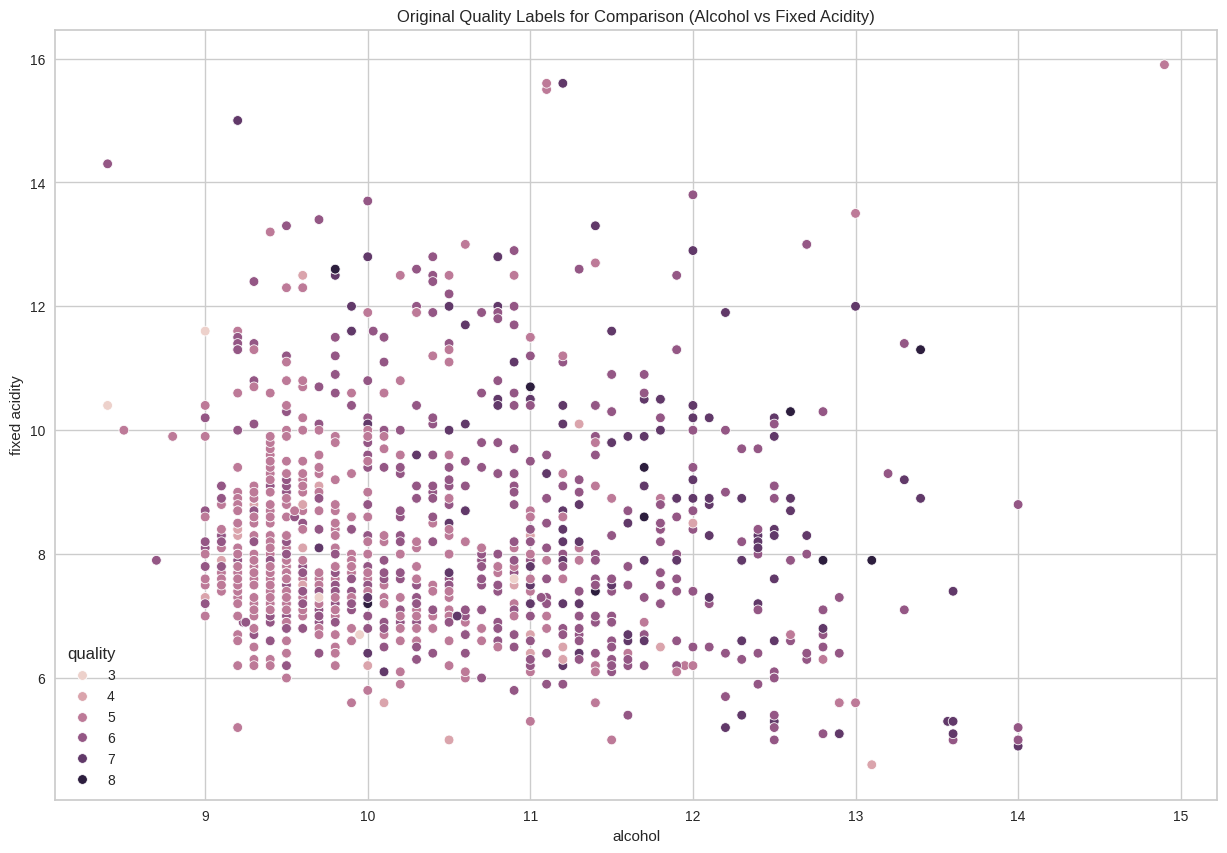

In [40]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='quality')
plt.title('Original Quality Labels for Comparison (Alcohol vs Fixed Acidity)')

### Tulis Interpretasi dari hasil evaluasi diatas :

1.  **Konsistensi Jumlah Cluster (K):** Baik **Metode Elbow** maupun **Via-Score Plot** sama-sama mengindikasikan bahwa jumlah cluster optimal adalah **3**. Ini menunjukkan konsistensi dalam penentuan struktur data laten.
2.  **Perbandingan dengan Label Asli ('quality'):** Ketika hasil clustering (baik dari Elbow maupun Via-Score) divisualisasikan dan dibandingkan dengan label 'quality' asli, terlihat ada korelasi visual yang cukup baik.
    *   Meskipun clustering adalah metode unsupervised dan tidak secara langsung 'melihat' label 'quality', kelompok-kelompok yang terbentuk berdasarkan 'alcohol' dan 'fixed acidity' cenderung memisahkan data dengan kualitas yang berbeda.
    *   Sebagai contoh, satu cluster mungkin berisi sebagian besar anggur berkualitas rendah, sementara cluster lain didominasi oleh anggur berkualitas menengah atau tinggi. Ini menunjukkan bahwa 'alcohol' dan 'fixed acidity' adalah fitur yang relevan dalam membedakan kualitas anggur.
3.  **Implikasi:** Kesamaan hasil dari kedua metode dan kesesuaian visual dengan label 'quality' asli menunjukkan bahwa model K-Means dengan 3 cluster cukup baik dalam mengidentifikasi pola pengelompokan alami dalam dataset WineQT berdasarkan kadar alkohol dan keasaman tetap.